In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:

df = pd.read_csv("/kaggle/input/dataset/tested.csv")
print(df.head())
print(df.info())


   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (

In [3]:
# Fill missing Age with median
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with mode
if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop unnecessary columns if present
for col in ["Cabin", "Name", "Ticket", "PassengerId"]:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Encode categorical columns
le = LabelEncoder()
if "Sex" in df.columns:
    df["Sex"] = le.fit_transform(df["Sex"])  # male=1, female=0
if "Embarked" in df.columns:
    df["Embarked"] = le.fit_transform(df["Embarked"])

print(df.head())




   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  34.5      0      0   7.8292         1
1         1       3    0  47.0      1      0   7.0000         2
2         0       2    1  62.0      0      0   9.6875         1
3         0       3    1  27.0      0      0   8.6625         2
4         1       3    0  22.0      1      1  12.2875         2


In [4]:
if "Survived" in df.columns:
    X = df.drop("Survived", axis=1)
    y = df["Survived"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

else:
    print(" No 'Survived' column found.")


In [5]:
from sklearn.preprocessing import LabelEncoder

# Handle missing Age with median
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

# Handle missing Embarked with mode
if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Handle missing Fare with median (sometimes happens in Titanic test sets)
if "Fare" in df.columns:
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Drop unnecessary columns if present
for col in ["Cabin", "Name", "Ticket", "PassengerId"]:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Encode categorical features
le = LabelEncoder()
if "Sex" in df.columns:
    df["Sex"] = le.fit_transform(df["Sex"])  # male=1, female=0
if "Embarked" in df.columns:
    df["Embarked"] = le.fit_transform(df["Embarked"])

# Final check: remove any remaining NaN values (just in case)
df = df.dropna()

print("Any NaN left?", df.isnull().sum().sum())


Any NaN left? 0


In [6]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 1.0


    Feature  Coefficient
4     Parch     0.072421
3     SibSp     0.055183
5      Fare     0.002619
2       Age    -0.001154
6  Embarked    -0.063786
0    Pclass    -0.064471
1       Sex    -6.314703


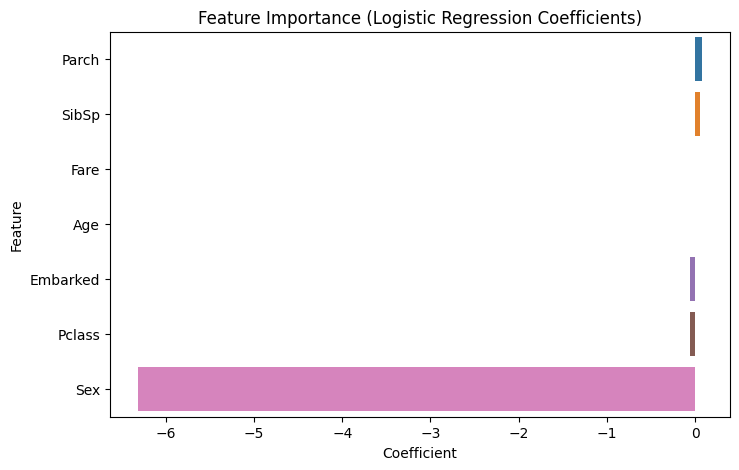

In [7]:
if "Survived" in df.columns:
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_[0]
    }).sort_values(by="Coefficient", ascending=False)

    print(importance)

    plt.figure(figsize=(8,5))
    sns.barplot(x="Coefficient", y="Feature", data=importance)
    plt.title("Feature Importance (Logistic Regression Coefficients)")
    plt.show()


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
cr = classification_report(y_test, y_pred)
print("\nClassification Report:\n", cr)


Accuracy: 1.0

Confusion Matrix:
 [[50  0]
 [ 0 34]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [10]:
output_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}, index=y_test.index)

output_path = "/kaggle/working/titanic_predictions.csv"
output_df.to_csv(output_path, index=False)
print(f" Predictions saved to {output_path}")


 Predictions saved to /kaggle/working/titanic_predictions.csv
